##Mount Google Drive (If running on Colab)

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Setup

In [7]:
# !pip install pandas numpy torch matplotlib scikit-learn
import os, math, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

### Move scripts from Drive to Colab

In [15]:
!cp -r "/content/drive/MyDrive/ML_projects/anomaly-detection/dataloader.py" "/content/"
!cp -r "/content/drive/MyDrive/ML_projects/anomaly-detection/model_LSTMAE.py" "/content/"
!cp -r "/content/drive/MyDrive/ML_projects/anomaly-detection/evaluate.py" "/content/"

### Set seeds & device:

In [8]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 2. Load NASA Turbofan Jet Engine Data Set: FD001

In [9]:
# Path to your extracted CMAPSS files
DATA_DIR = "/content/drive/MyDrive/Datasets/CMaps"  # <-- change this
TRAIN_FILE = os.path.join(DATA_DIR, "train_FD001.txt")
TEST_FILE  = os.path.join(DATA_DIR, "test_FD001.txt")

# Column names: id, cycle, 3 op settings, 21 sensors = 26 columns total
cols = (["engine_id","cycle","op1","op2","op3"] +
        [f"s{i}" for i in range(1,22)])

def load_fd001(path):
    df = pd.read_csv(path, sep=r"\s+", header=None, names=cols)
    # defensive: sometimes trailing empty column sneaks in; drop if present
    df = df.loc[:, cols]
    return df

train_df = load_fd001(TRAIN_FILE)
test_df  = load_fd001(TEST_FILE)

print(train_df.shape, train_df.head())


(20631, 26)    engine_id  cycle     op1     op2    op3      s1      s2       s3       s4  \
0          1      1 -0.0007 -0.0004  100.0  518.67  641.82  1589.70  1400.60   
1          1      2  0.0019 -0.0003  100.0  518.67  642.15  1591.82  1403.14   
2          1      3 -0.0043  0.0003  100.0  518.67  642.35  1587.99  1404.20   
3          1      4  0.0007  0.0000  100.0  518.67  642.35  1582.79  1401.87   
4          1      5 -0.0019 -0.0002  100.0  518.67  642.37  1582.85  1406.22   

      s5  ...     s12      s13      s14     s15   s16  s17   s18    s19  \
0  14.62  ...  521.66  2388.02  8138.62  8.4195  0.03  392  2388  100.0   
1  14.62  ...  522.28  2388.07  8131.49  8.4318  0.03  392  2388  100.0   
2  14.62  ...  522.42  2388.03  8133.23  8.4178  0.03  390  2388  100.0   
3  14.62  ...  522.86  2388.08  8133.83  8.3682  0.03  392  2388  100.0   
4  14.62  ...  522.19  2388.04  8133.80  8.4294  0.03  393  2388  100.0   

     s20      s21  
0  39.06  23.4190  
1  39.00  23.423

### Basic utilities

In [10]:
FEATURES = ["op1","op2","op3"] + [f"s{i}" for i in range(1,22)]  # 24 features
OPS = ["op1","op2","op3"]
SENSORS = [f"s{i}" for i in range(1,22)]

def per_engine_lengths(df):
    return df.groupby("engine_id")["cycle"].max().to_dict()

# Drop near-constant sensors (optional but helpful):
def drop_low_variance(df, feats, thr=1e-3):
    std = df[feats].std()
    keep = [f for f in feats if std[f] > thr]
    dropped = [f for f in feats if f not in keep]
    return keep, dropped

# Compute on train only (entire train for stability)
kept_features, dropped = drop_low_variance(train_df, FEATURES, thr=1e-3)
print("Dropped (low-var):", dropped)
print("Kept:", len(kept_features), "features")

Dropped (low-var): ['op2', 'op3', 's1', 's5', 's10', 's16', 's18', 's19']
Kept: 16 features


## 3. Prepare dataset for Train and Inference

### Split engines into train/val (engine-level split)

We’ll learn the threshold from healthy windows of a held-out validation engine set.

In [11]:
engines = sorted(train_df["engine_id"].unique())
random.shuffle(engines)
val_frac = 0.2
val_n = max(1, int(len(engines)*val_frac))
val_engines = set(engines[:val_n])
train_engines = set(engines[val_n:])
print(f"# engines train={len(train_engines)} val={len(val_engines)}")

# engines train=80 val=20


### Healthy window selection + normalization

We’ll treat first 30% cycles of each engine as “healthy.”
Scale features using only healthy windows from train engines.

In [12]:
HEALTHY_FRAC = 0.30
WIN = 30
STRIDE = 1

def engine_healthy_end(df, eid, frac=HEALTHY_FRAC):
    n = df.loc[df.engine_id==eid, "cycle"].max()
    return int(math.floor(n*frac))

def make_windows_1engine(arr, win=WIN, stride=STRIDE):
    # arr shape: (num_cycles, num_features)
    out = []
    for start in range(0, arr.shape[0] - win + 1, stride):
        out.append(arr[start:start+win])
    if not out:
        return np.empty((0, win, arr.shape[1]))
    return np.stack(out, axis=0)  # (num_windows, win, feat)

# 4.1 collect healthy rows for scaler (train engines only)
train_healthy_rows = []
for eid in train_engines:
    e = train_df[train_df.engine_id==eid].sort_values("cycle")
    cutoff = engine_healthy_end(train_df, eid)
    healthy_e = e[e.cycle<=cutoff]
    train_healthy_rows.append(healthy_e[kept_features].values)
train_healthy_rows = np.vstack(train_healthy_rows)

# 4.2 fit scaler on those healthy rows
scaler = StandardScaler().fit(train_healthy_rows)

def scale_df(df, feats):
    scaled = df.copy()
    scaled[feats] = scaler.transform(scaled[feats].values)
    return scaled

train_scaled = scale_df(train_df, kept_features)
test_scaled  = scale_df(test_df,  kept_features)

### Build window datasets

Training windows: healthy windows from train engines only.
Validation windows: healthy windows from val engines only.
Test windows: full-life windows from all engines (for scoring/plots).

We’ll also keep (engine_id, end_cycle) for each window to align scores back to the timeline.

In [13]:
def windows_from_engines(df_scaled, engines_set, healthy_only=True):
    X, meta = [], []
    for eid in sorted(engines_set):
        e = df_scaled[df_scaled.engine_id==eid].sort_values("cycle")
        cutoff = engine_healthy_end(df_scaled, eid)
        if healthy_only:
            e = e[e.cycle<=cutoff]
        feats = e[kept_features].values  # (T, F)
        w = make_windows_1engine(feats, WIN, STRIDE)
        # meta: (engine_id, end_cycle_of_window)
        if w.shape[0]>0:
            ends = e["cycle"].values[WIN-1::STRIDE]
            meta.extend([(eid, int(c)) for c in ends])
            X.append(w)
    if len(X)==0:
        return np.empty((0,WIN,len(kept_features))), []
    return np.concatenate(X, axis=0), meta

X_train, _   = windows_from_engines(train_scaled, train_engines, healthy_only=True)
X_val,   _   = windows_from_engines(train_scaled, val_engines,   healthy_only=True)

# For scoring later (full life of all train engines)
X_full_train, meta_full_train = windows_from_engines(train_scaled, set(engines), healthy_only=False)
print("Train healthy windows:", X_train.shape, "Val healthy windows:", X_val.shape)
print("Full-train windows for scoring:", X_full_train.shape)

# Test set (test engines are separate ids; treat all as full life)
test_engines = sorted(test_scaled.engine_id.unique())
X_test, meta_test = windows_from_engines(test_scaled, set(test_engines), healthy_only=False)
print("Test windows:", X_test.shape)

Train healthy windows: (2547, 30, 16) Val healthy windows: (697, 30, 16)
Full-train windows for scoring: (17731, 30, 16)
Test windows: (10196, 30, 16)


## 4. Load windowed data into dataloader and define a LSTM Autoencoder model

### PyTorch Dataset/DataLoader

In [16]:
from dataloader import WindowDataset

batch_size = 64
dl_train = DataLoader(WindowDataset(X_train), batch_size=batch_size, shuffle=True, drop_last=True)
dl_val   = DataLoader(WindowDataset(X_val),   batch_size=batch_size, shuffle=False, drop_last=False)

### instantiate LSTM Autoencoder model

In [17]:
from model_LSTMAE import LSTMAE
feat_dim = len(kept_features)
model = LSTMAE(feat_dim, hidden=64, latent=32, num_layers=1, dropout=0.2).to(device)
optim = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

### Set path to save checkpoints

In [18]:
save_dir_ck = "/content/drive/MyDrive/ML_projects/anomaly-detection/runs"
os.makedirs(save_dir_ck, exist_ok=True)

## 5. Train

In [ ]:
def evaluate_mse(dataloader):
    model.eval()
    losses = []
    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device); y = y.to(device)
            yhat = model(x)
            loss = criterion(yhat, y).item()
            losses.append(loss)
    return float(np.mean(losses)) if losses else np.nan

EPOCHS = 500
best_val = float("inf")
patience, patience_ctr = 8, 0
for epoch in range(1, EPOCHS+1):
    model.train()
    for x, y in dl_train:
        x = x.to(device); y = y.to(device)
        yhat = model(x)
        loss = criterion(yhat, y)
        optim.zero_grad(); loss.backward(); optim.step()

    tr = evaluate_mse(dl_train)
    va = evaluate_mse(dl_val)
    print(f"Epoch {epoch:02d} | train {tr:.6f} | val {va:.6f}")

    if va < best_val - 1e-5:
        best_val = va; patience_ctr = 0
        save_path = os.path.join(save_dir_ck, "lstm_ae_fd001.pt")
        torch.save(model.state_dict(), save_path)
    else:
        patience_ctr += 1
        if patience_ctr >= patience:
            print("Early stop.")
            break

Epoch 01 | train 0.001633 | val 0.002332
Epoch 02 | train 0.001585 | val 0.002268
Epoch 03 | train 0.001539 | val 0.002208
Epoch 04 | train 0.001497 | val 0.002152
Epoch 05 | train 0.001453 | val 0.002102
Epoch 06 | train 0.001413 | val 0.002044
Epoch 07 | train 0.001375 | val 0.001996
Epoch 08 | train 0.001335 | val 0.001936
Epoch 09 | train 0.001302 | val 0.001894
Epoch 10 | train 0.001276 | val 0.001865
Epoch 11 | train 0.001244 | val 0.001812
Epoch 12 | train 0.001206 | val 0.001766
Epoch 13 | train 0.001175 | val 0.001730
Epoch 14 | train 0.001144 | val 0.001681
Epoch 15 | train 0.001121 | val 0.001652
Epoch 16 | train 0.001097 | val 0.001616
Epoch 17 | train 0.001063 | val 0.001576
Epoch 18 | train 0.001035 | val 0.001536
Epoch 19 | train 0.001010 | val 0.001505
Epoch 20 | train 0.000984 | val 0.001467
Epoch 21 | train 0.000961 | val 0.001431
Epoch 22 | train 0.000944 | val 0.001409
Epoch 23 | train 0.000919 | val 0.001374
Epoch 24 | train 0.000901 | val 0.001347
Epoch 25 | train

### Load the trained model weights

In [19]:
# load best
ckt_path = os.path.join(save_dir_ck, "lstm_ae_fd001.pt")
model.load_state_dict(torch.load(ckt_path, map_location=device))
model.eval()

LSTMAE(
  (encoder): LSTM(16, 64, batch_first=True)
  (enc_to_latent): Linear(in_features=64, out_features=32, bias=True)
  (latent_to_dec): Linear(in_features=32, out_features=64, bias=True)
  (decoder): LSTM(16, 64, batch_first=True)
  (out): Linear(in_features=64, out_features=16, bias=True)
)

## 6. Inference

### Compute Anomaly scores (window-level reconstruction errors)



In [20]:
from evaluate import window_mse_scores

In [21]:
# Compute for val-healthy (to set threshold), full train, test:
scores_val_healthy = window_mse_scores(X_val, WindowDataset(X_val), model,device)
thr = np.percentile(scores_val_healthy, 99)   # 99th percentile threshold
print("Threshold (99th pct of val-healthy):", thr)

scores_train_full = window_mse_scores(X_full_train, WindowDataset(X_full_train), model,device)
scores_test = window_mse_scores(X_test,WindowDataset(X_test), model,device)


Threshold (99th pct of val-healthy): 0.0005266202148050066


### Save to CSV with metadata:

In [22]:
def save_scores_csv(scores, meta, filename):
    df = pd.DataFrame(meta, columns=["engine_id", "end_cycle"])
    df["mse"] = scores
    out_csv = os.path.join(save_dir_ck, filename)
    df.to_csv(out_csv, index=False)
    print("Saved:", out_csv)

# Save all three
save_scores_csv(scores_val_healthy, [(999, i) for i in range(len(scores_val_healthy))], "scores_valHealthy.csv")
save_scores_csv(scores_train_full, meta_full_train, "scores_trainFull.csv")
save_scores_csv(scores_test, meta_test, "scores_test.csv")


Saved: /content/drive/MyDrive/ML_projects/anomaly-detection/runs/scores_valHealthy.csv
Saved: /content/drive/MyDrive/ML_projects/anomaly-detection/runs/scores_trainFull.csv
Saved: /content/drive/MyDrive/ML_projects/anomaly-detection/runs/scores_test.csv


### Compute detection metrics

False alarm on val-healthy should be ≈ 1% by design.

Early warning: first cycle where score > threshold (report median lead time vs last cycle per engine).

In [23]:
def healthy_fpr(scores, thr):
    return float((scores>thr).mean())

print("Val-healthy FPR (should be ~0.01):", healthy_fpr(scores_val_healthy, thr))

def first_detection_lead_time(scores_csv, df_raw):
    """
    For each engine, report (last_cycle - first_detect_cycle).
    """
    df = pd.read_csv(scores_csv)
    out = []
    for eid, d in df.groupby("engine_id"):
        last_cyc = int(df_raw[df_raw.engine_id==eid]["cycle"].max())
        d = d.sort_values("end_cycle")
        idx = np.where(d["mse"].values > thr)[0]
        if len(idx)==0:
            continue
        first_cyc = int(d.iloc[idx[0]]["end_cycle"])
        out.append(last_cyc - first_cyc)
    return out

lead_train = first_detection_lead_time(os.path.join(save_dir_ck, "scores_trainFull.csv"), train_df)
lead_test  = first_detection_lead_time(os.path.join(save_dir_ck,"scores_test.csv"), test_df)
print("Median lead time (train engines):", np.median(lead_train) if lead_train else "NA")
print("Median lead time (test engines):",  np.median(lead_test)  if lead_test  else "NA")

Val-healthy FPR (should be ~0.01): 0.010043041606886656
Median lead time (train engines): 61.0
Median lead time (test engines): 27.0


### plot of the per-engine anomaly curve

In [24]:
def plot_engine(scores_csv, engine_id, threshold=thr, title_prefix="Train"):
    df = pd.read_csv(scores_csv)
    d = df[df.engine_id==engine_id].sort_values("end_cycle")
    if d.empty:
        print("No windows for engine", engine_id, "in", scores_csv); return
    plt.figure(figsize=(8,3))
    plt.plot(d["end_cycle"], d["mse"], label="AE MSE")
    plt.axhline(threshold, linestyle="--", label="threshold")
    plt.xlabel("Cycle (window end)")
    plt.ylabel("Anomaly score (MSE)")
    plt.title(f"{title_prefix} Engine {engine_id}: anomaly score vs cycle")
    plt.legend(); plt.tight_layout(); plt.show()

### Example: Plot the anomaly curve for a train engine

For a train engine that runs until failure, the anomaly score (MSE) stays low and stable during early cycles but rises sharply near the end of life.
This increasing trend reflects the growing deviation from healthy operating patterns as the engine approaches failure.

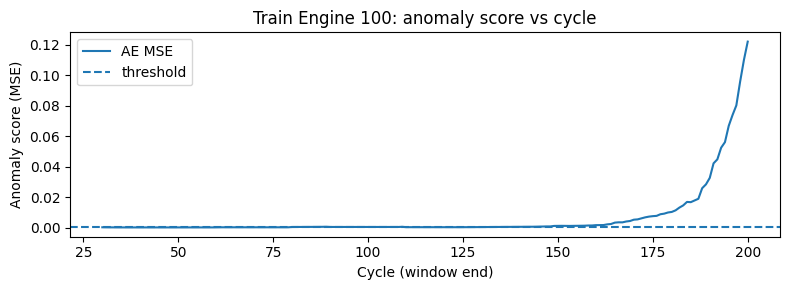

In [25]:
engineID=100
plot_engine(os.path.join(save_dir_ck, "scores_trainFull.csv"), engine_id=engineID,  title_prefix="Train")

### Example: plot the curve for test engines.

We compare test engines with relatively low and high Remaining Useful Life (RUL) values to visualize how the autoencoder’s anomaly scores evolve over time.

🔹 Low-RUL Engine (near failure)

For engines operating close to failure, the anomaly score (MSE) remains low and stable during early cycles but rises sharply toward the end of life, passing the healthy validation-set error thresold.
This behavior indicates that the model effectively recognizes deviations from healthy operating patterns and detects the onset of degradation.

🔹 High-RUL Engine (still healthy)

For engines with high remaining life, the anomaly score stays consistently below the healthy validation-set threshold, showing no significant increase near the end.
This suggests that the engine continues to operate normally and the model correctly identifies it as healthy.

In [26]:
import pandas as pd
import os

DATA_DIR = "/content/drive/MyDrive/Datasets/CMaps"  # <-- change this  # change to your dataset path

# Load the RUL file (no header)
rul_df = pd.read_csv(os.path.join(DATA_DIR, "RUL_FD001.txt"),
                     header=None, names=["RUL"])

# Add engine IDs
rul_df["engine_id"] = rul_df.index + 1


#### Choose engines with low RULs

    engine_id  RUL
17         18   28
19         20   16
23         24   20
30         31    8
33         34    7
34         35   11
35         36   19
36         37   21
39         40   28
40         41   18
41         42   10
48         49   21
51         52   29
52         53   26
55         56   15
60         61   21
63         64   28
65         66   14
67         68    8
75         76   10
80         81    8
81         82    9
89         90   28
91         92   20
99        100   20


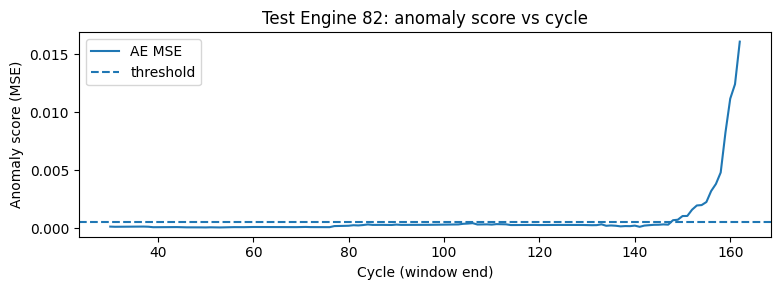

In [27]:
low_rul_df = rul_df.loc[rul_df["RUL"] < 30, ["engine_id", "RUL"]]
print(low_rul_df)
# Example: plot one test engine
plot_engine(os.path.join(save_dir_ck,"scores_test.csv"), engine_id=82,  title_prefix="Test")

#### Choose engines with high RULs

    engine_id  RUL
0           1  112
8           9  111
11         12  124
13         14  107
21         22  111
22         23  113
24         25  145
25         26  119
29         30  115
32         33  106
38         39  142
43         44  109
44         45  114
46         47  135
50         51  114
54         55  137
56         57  103
58         59  114
64         65  128
68         69  121
70         71  118
72         73  131
73         74  126
74         75  113
77         78  107
82         83  137
84         85  118
86         87  116
87         88  115
88         89  136
94         95  128
95         96  137
98         99  117


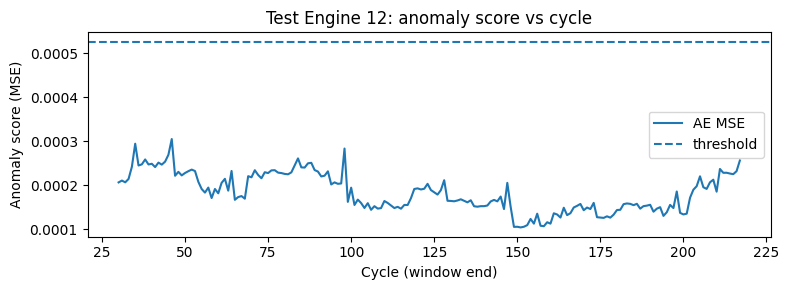

In [28]:
high_rul_df = rul_df.loc[rul_df["RUL"] > 100, ["engine_id", "RUL"]]
print(high_rul_df)
# Example: plot one test engine
plot_engine(os.path.join(save_dir_ck,"scores_test.csv"), engine_id=12,  title_prefix="Test")